# 02 - Análisis exploratorio mediante visualizaciones
**Proyecto:** StreamView Analytics - EP1 ADY1104 (Duoc UC)  
**Equipo:** Claudio Aro, Guillermo Cerda, Manuel Díaz

Cada figura responde una pregunta de negocio. Las figuras se guardan en `images/` y se reutilizan en el informe y la presentación.

In [1]:
import sys
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
import pandas as pd
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
from IPython.display import Image, display
from src import metricas as met, graficos as gr
cat, gen, pai = met.cargar_procesados()
tg = met.tabla_generos(cat, gen)

## KPIs del catálogo

In [2]:
pd.DataFrame({t: met.kpis(cat[cat.tipo == t]) for t in ["Película", "Serie"]} | {"Total": met.kpis(cat)}).round(2)

,Película,Serie,Total
titulos,16000.00,15991.00,31991.00
peliculas,16000.00,0.00,16000.00
series,0.00,15991.00,15991.00
votos_totales,11498498.00,1712228.00,13210726.00
votos_mediana,138.00,4.00,43.00
calif_media,6.38,7.12,6.71
pct_calif_alta,25.82,61.83,42.00
pct_baja_visibilidad,11.36,61.55,36.45
pct_top10_votos,70.99,85.90,79.18
roi_mediano,80.71,NaN,80.71


## P1. ¿Qué géneros generan interacción por sobre (o bajo) su peso en el catálogo?

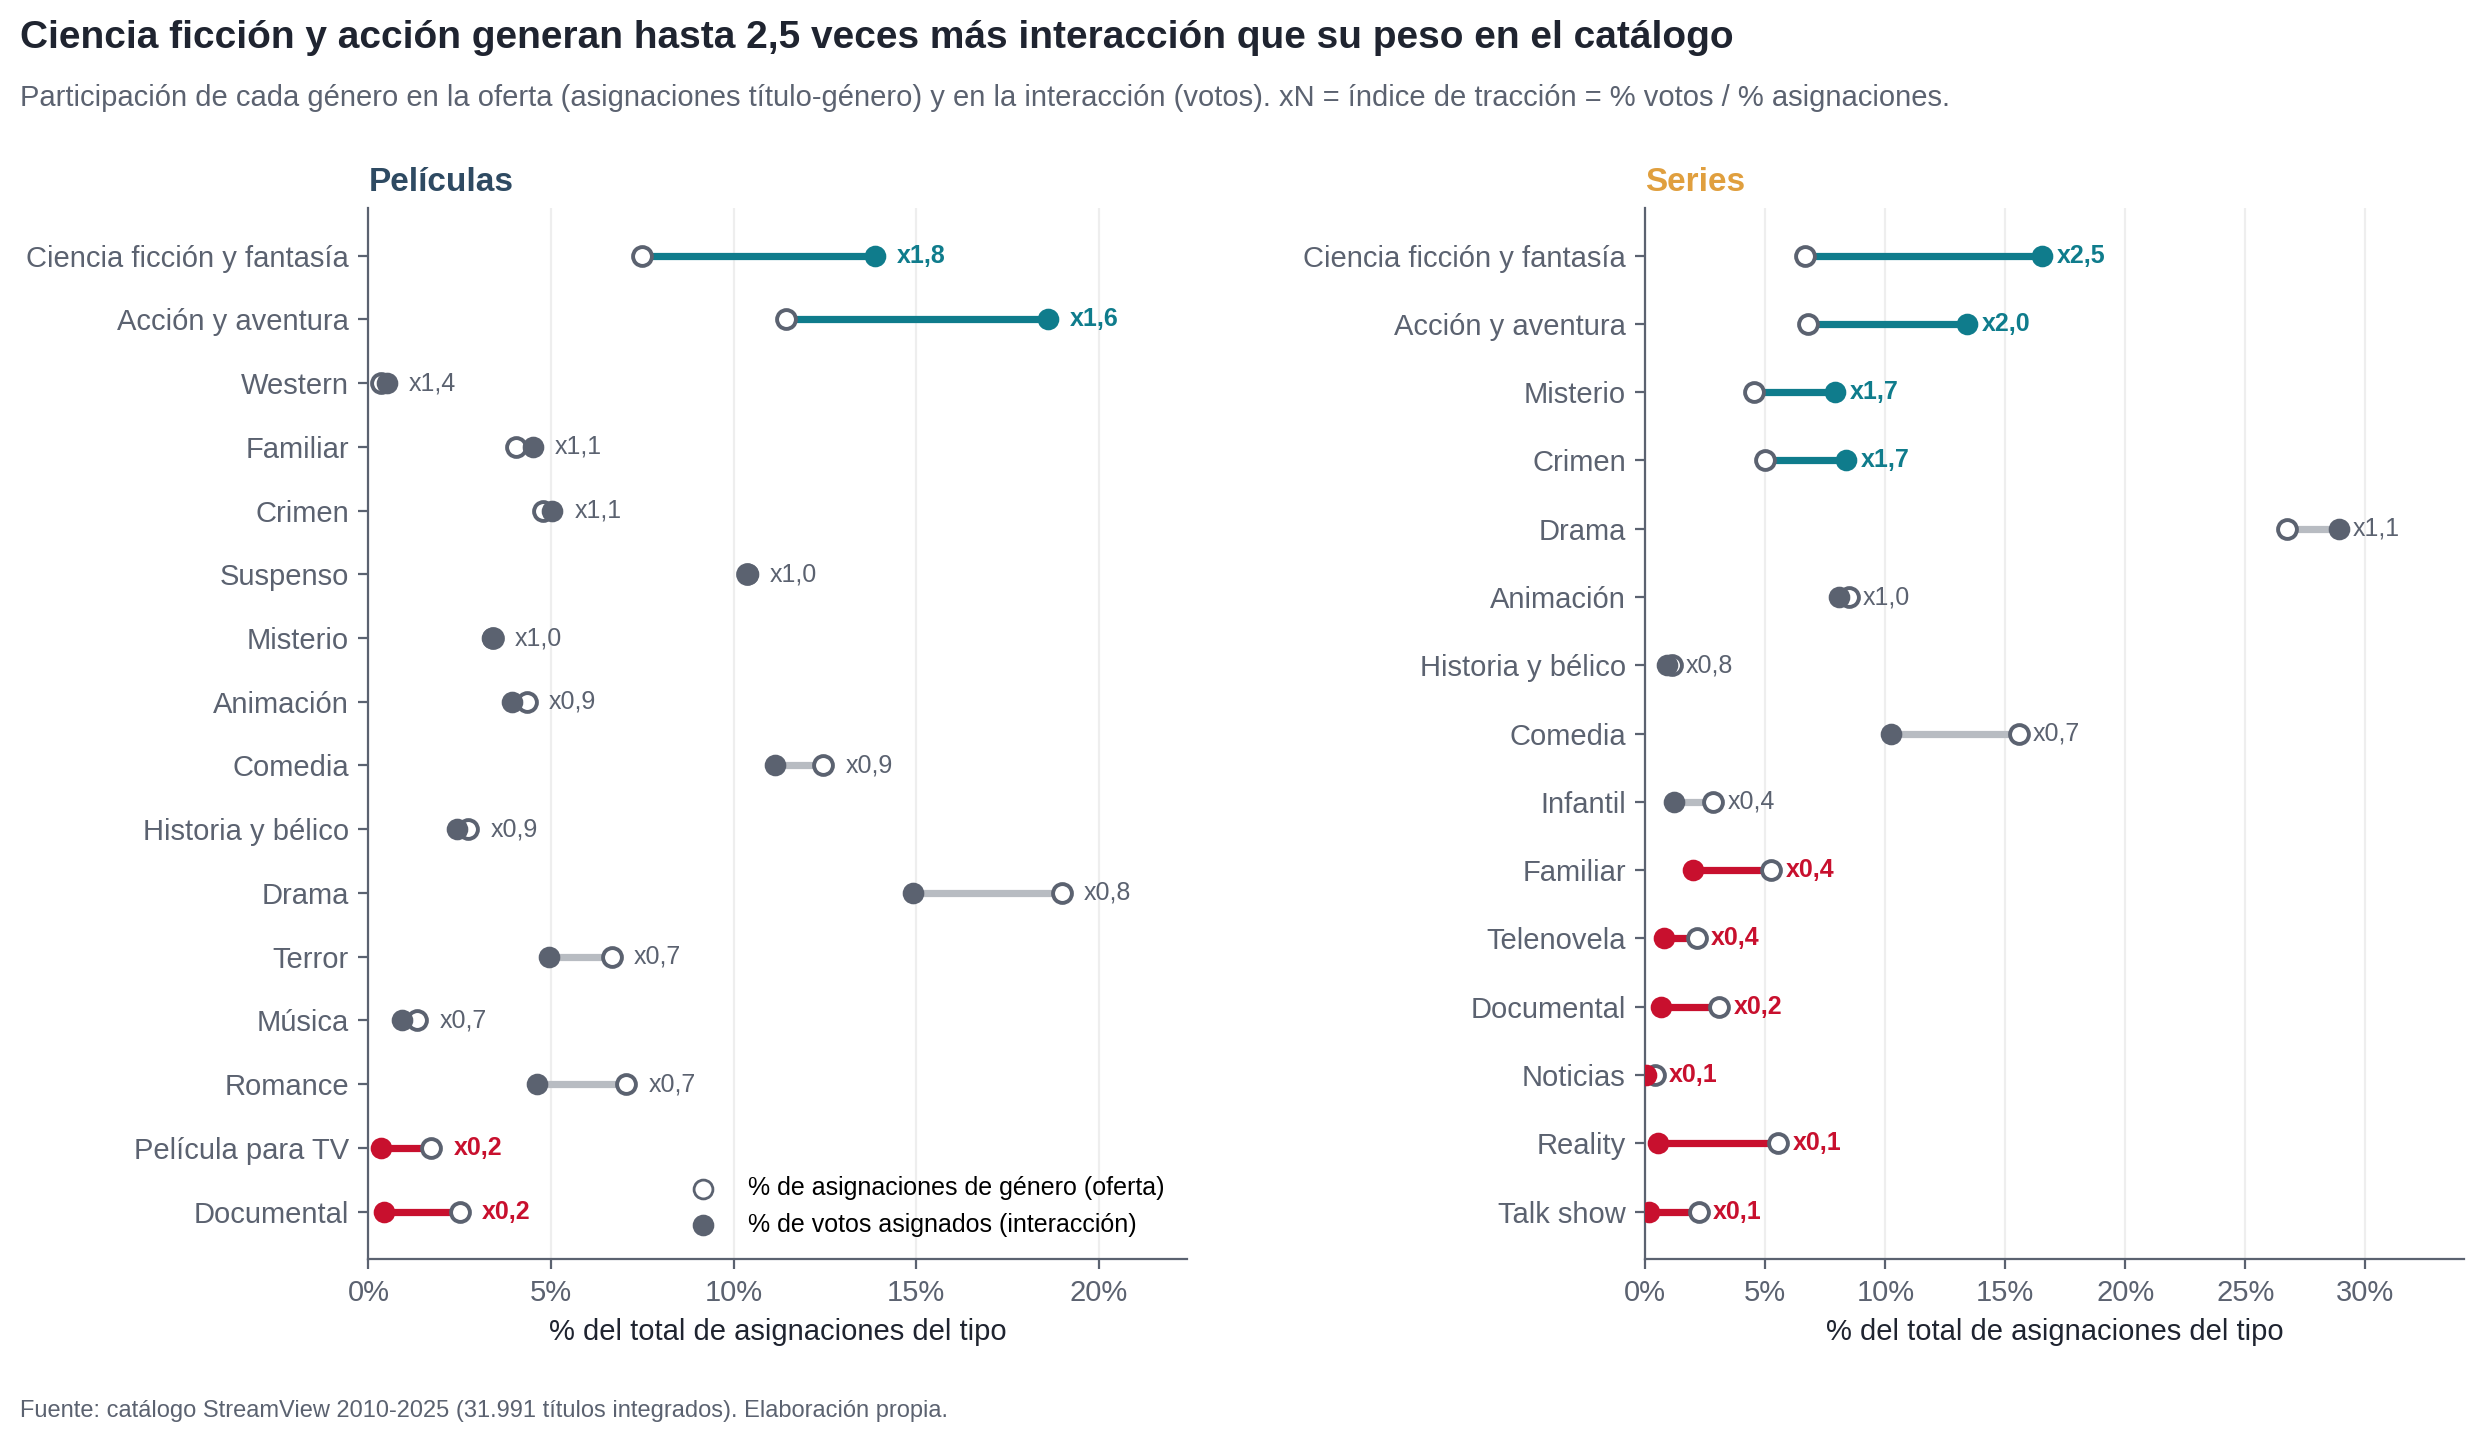

,tipo,genero,pct_titulos,pct_votos,indice_traccion
2,Película,Ciencia ficción y fantasía,7.50,13.88,1.85
0,Película,Acción y aventura,11.42,18.62,1.63
16,Película,Western,0.35,0.50,1.44
7,Película,Familiar,4.05,4.51,1.11
4,Película,Crimen,4.78,5.04,1.05
14,Película,Suspenso,10.36,10.39,1.00
9,Película,Misterio,3.41,3.38,0.99
1,Película,Animación,4.34,3.94,0.91
3,Película,Comedia,12.46,11.14,0.89
8,Película,Historia y bélico,2.74,2.44,0.89


In [3]:
display(Image(gr.fig_oferta_vs_interaccion(tg)))
tg.sort_values(["tipo", "indice_traccion"], ascending=[True, False])[["tipo","genero","pct_titulos","pct_votos","indice_traccion"]].round(2)

## P2. ¿Qué géneros son bien evaluados pero poco descubiertos (joyas ocultas)?

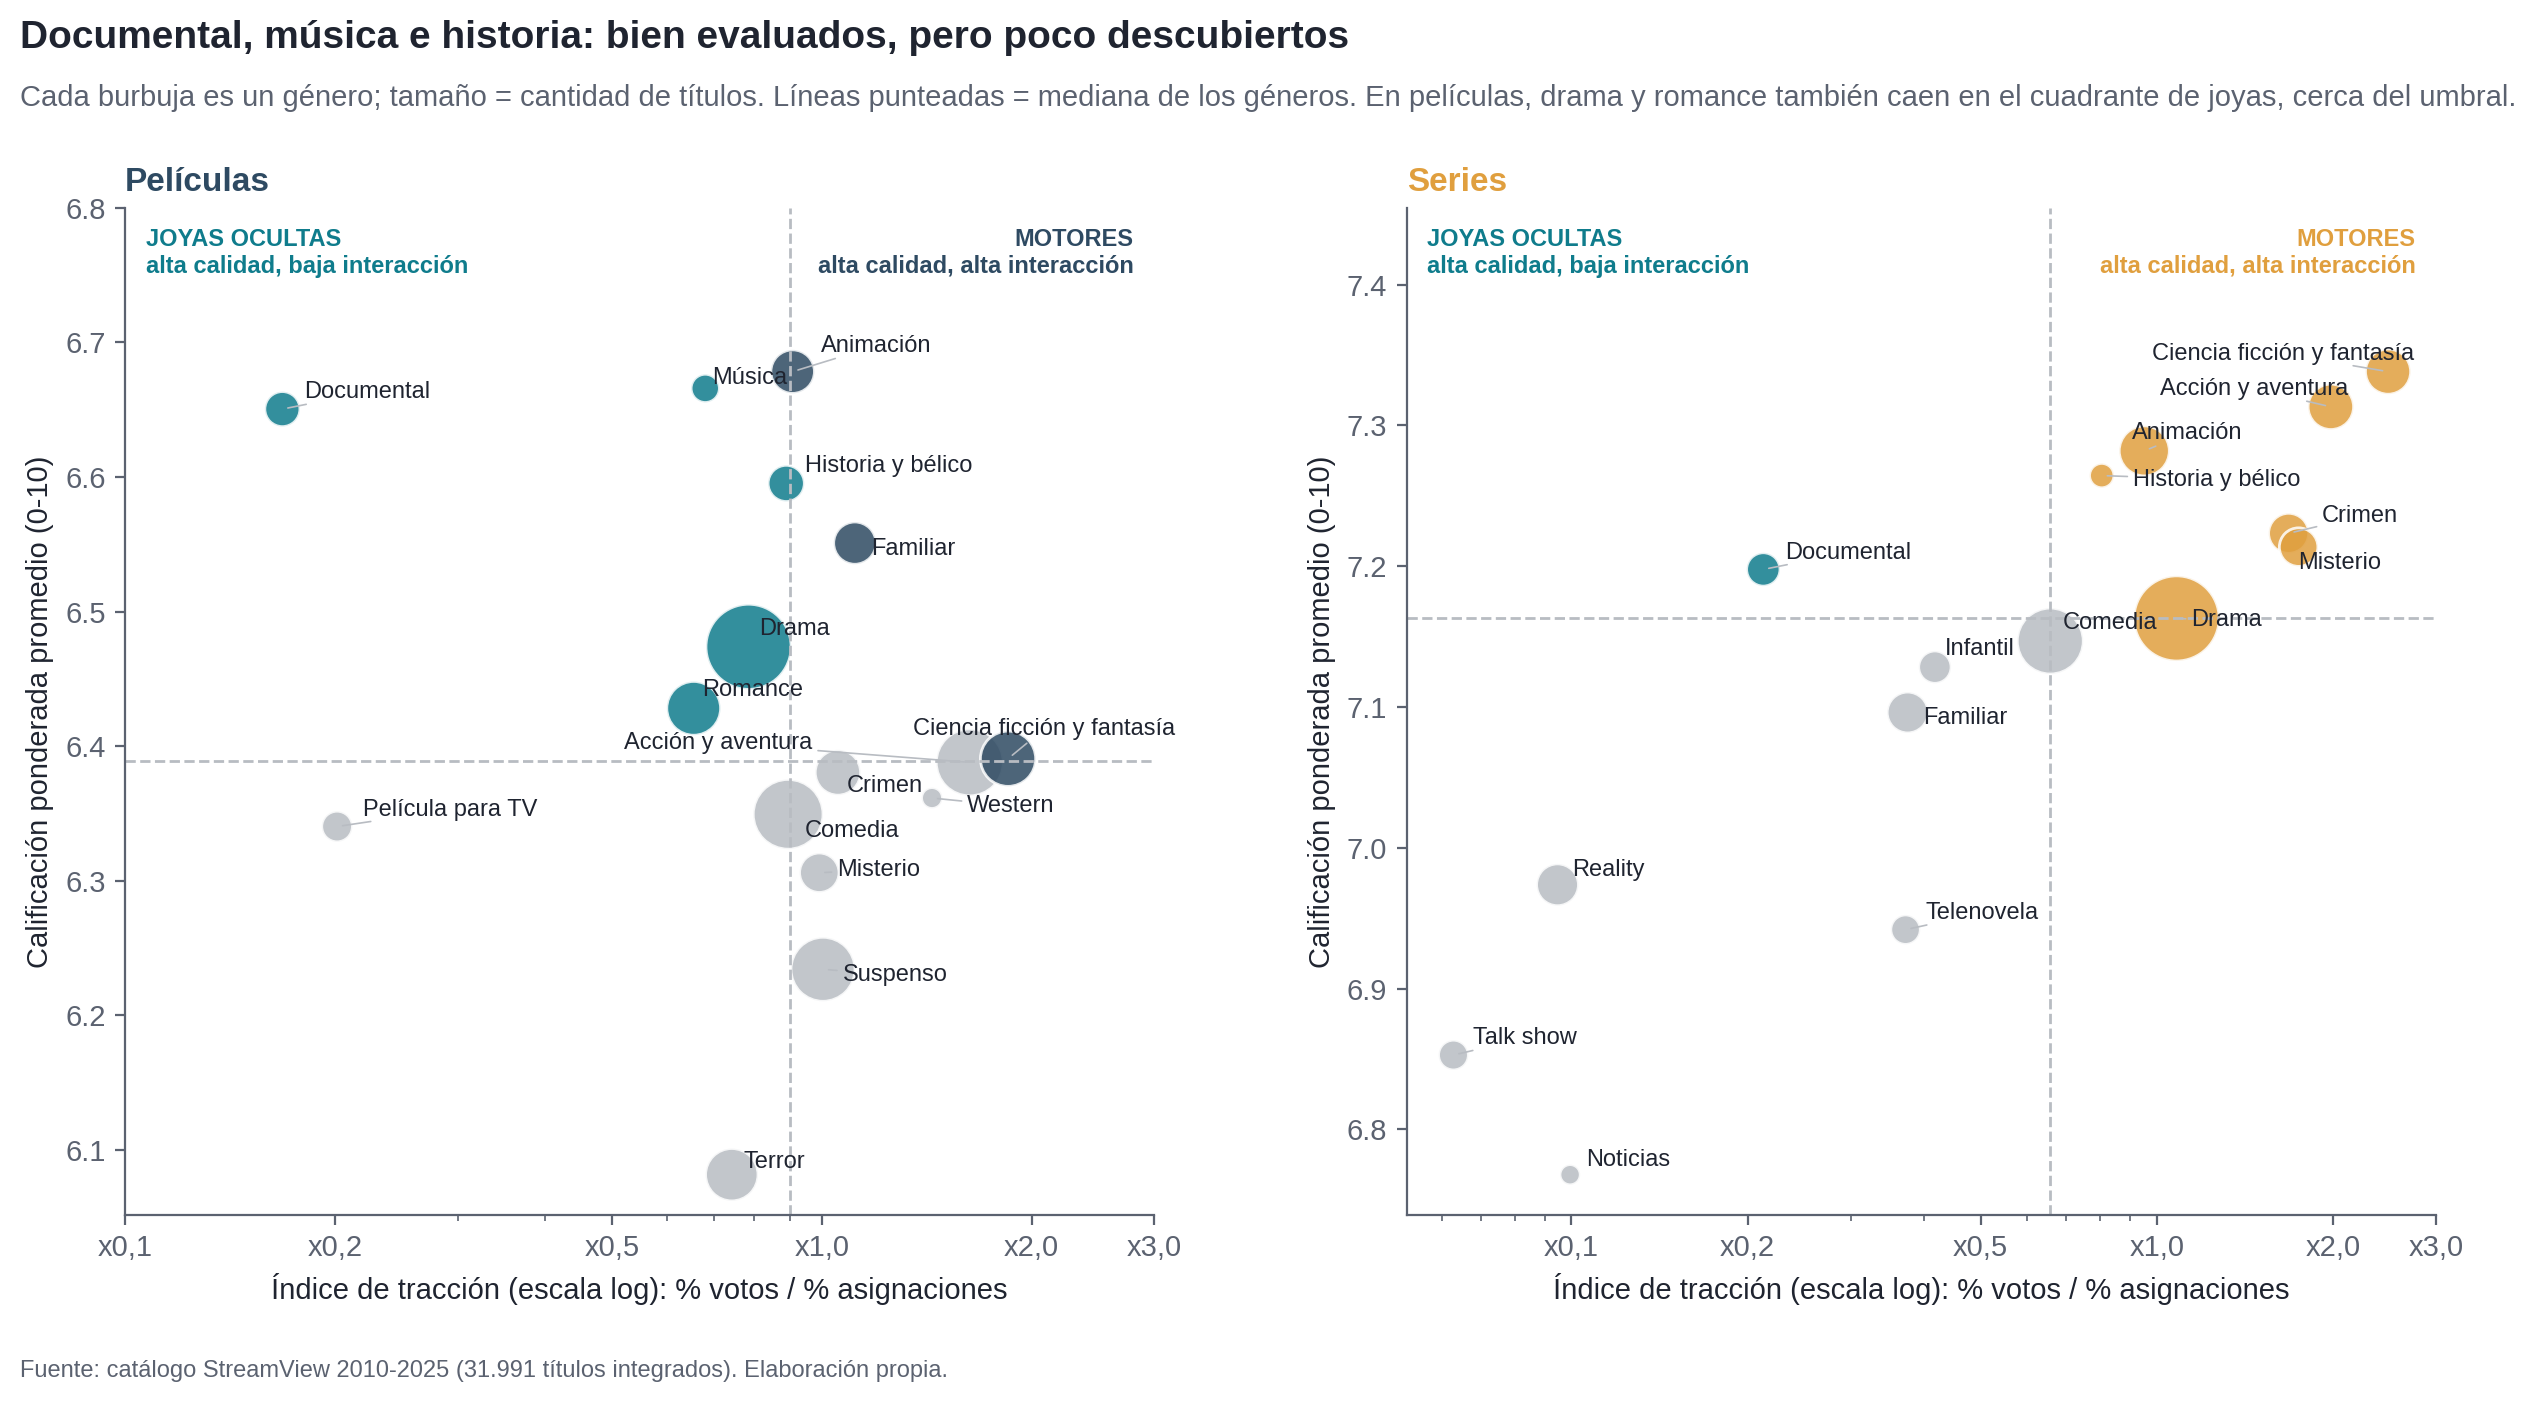

In [4]:
display(Image(gr.fig_matriz_calidad(tg)))

## P3. ¿Qué tan concentrada está la interacción?

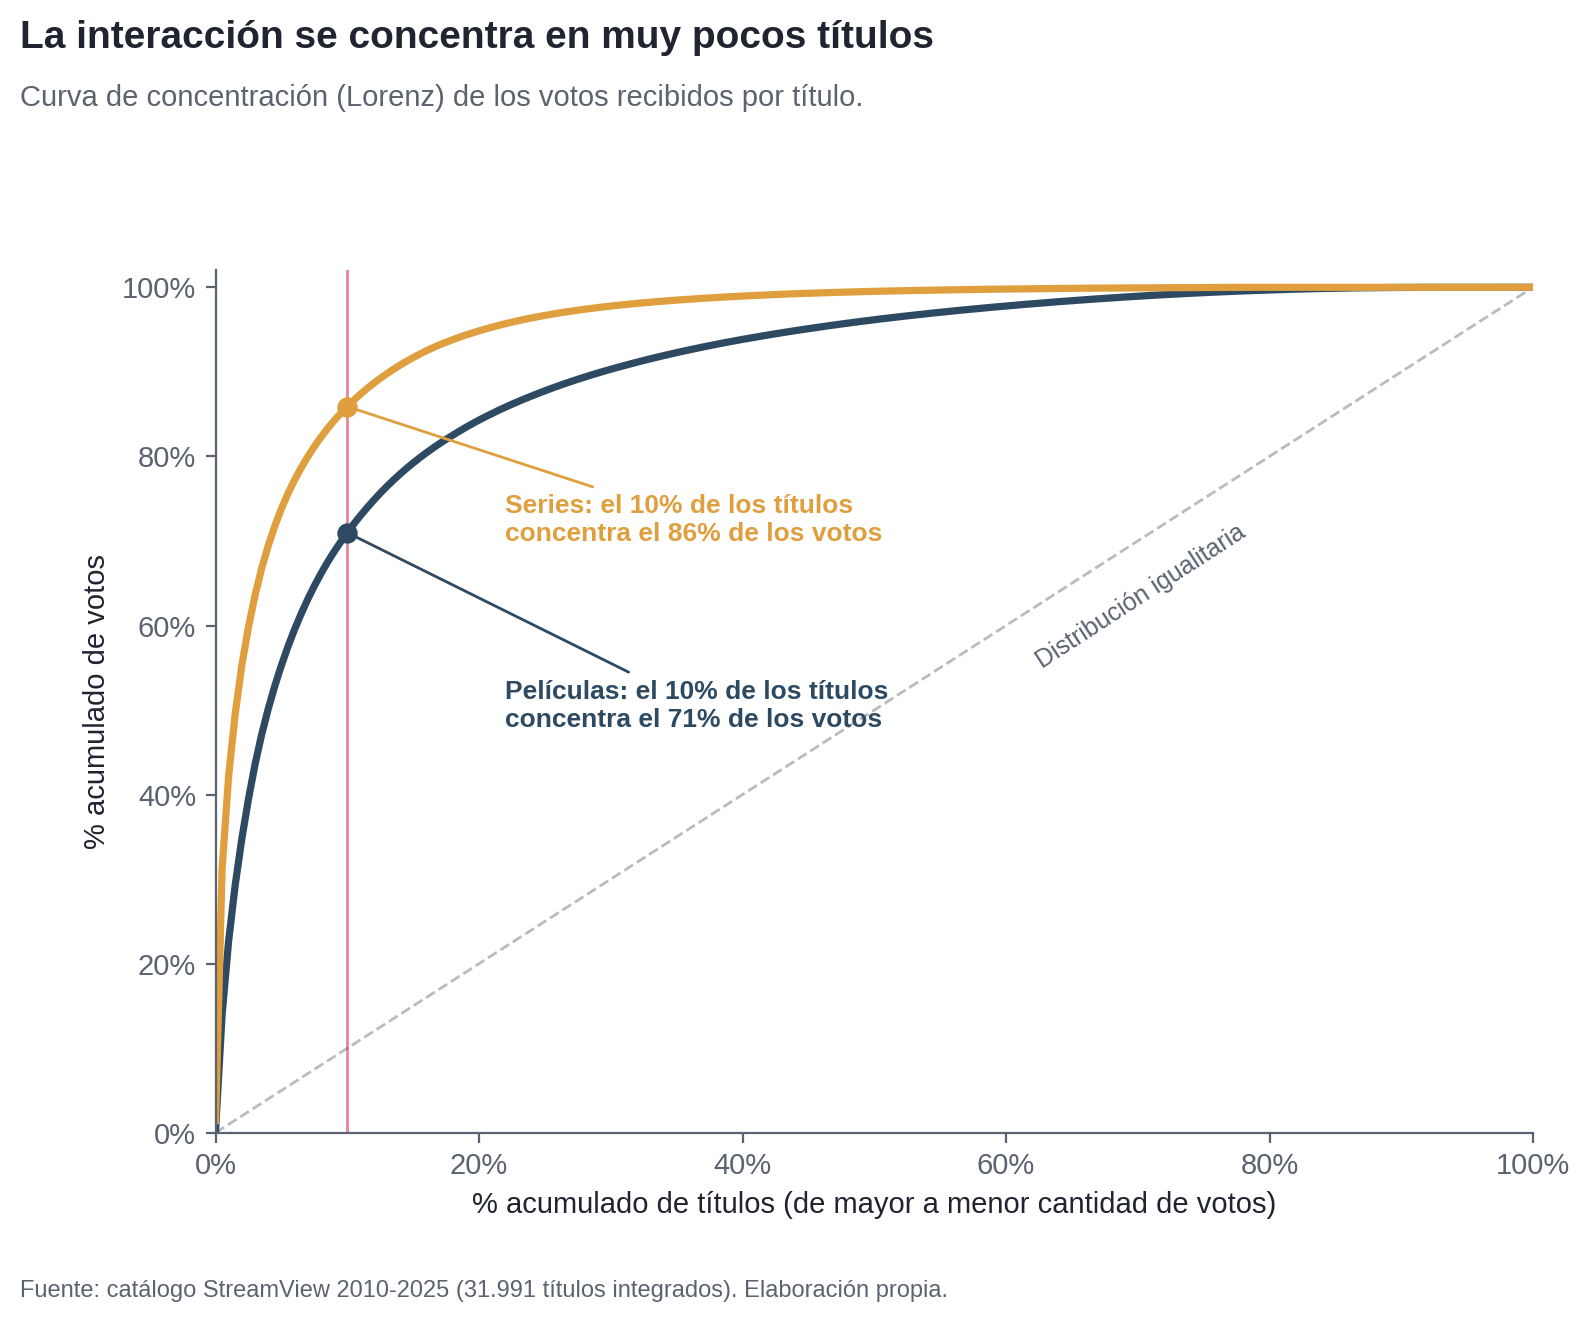

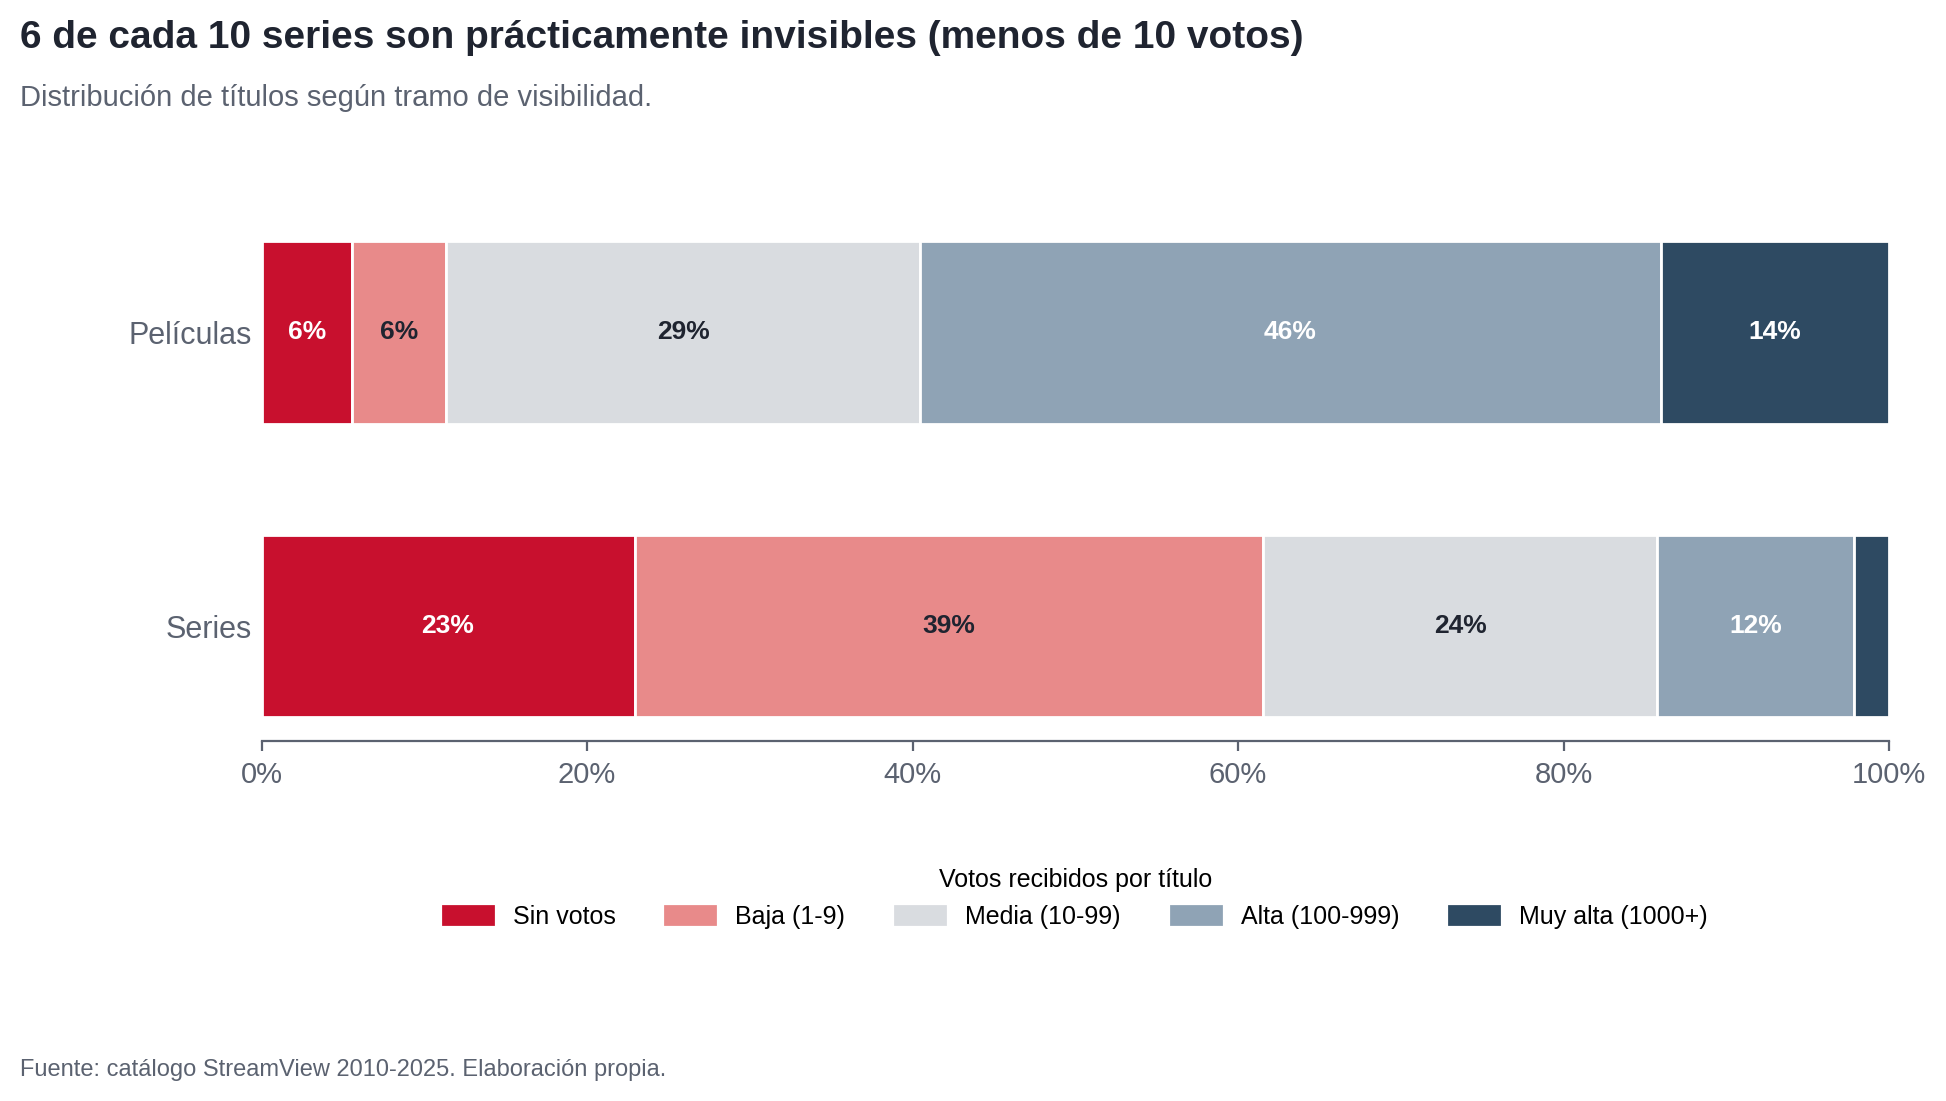

,tipo,visibilidad,titulos,pct
4,Película,Sin votos,894,5.6
1,Película,Baja (1-9),923,5.8
2,Película,Media (10-99),4655,29.1
0,Película,Alta (100-999),7288,45.6
3,Película,Muy alta (1000+),2240,14.0
9,Serie,Sin votos,3666,22.9
6,Serie,Baja (1-9),6177,38.6
7,Serie,Media (10-99),3871,24.2
5,Serie,Alta (100-999),1930,12.1
8,Serie,Muy alta (1000+),347,2.2


In [5]:
display(Image(gr.fig_concentracion(cat)))
display(Image(gr.fig_visibilidad(cat)))
met.tabla_visibilidad(cat).round(1)

## P4. ¿Qué idiomas ofrecen mejor calidad percibida?

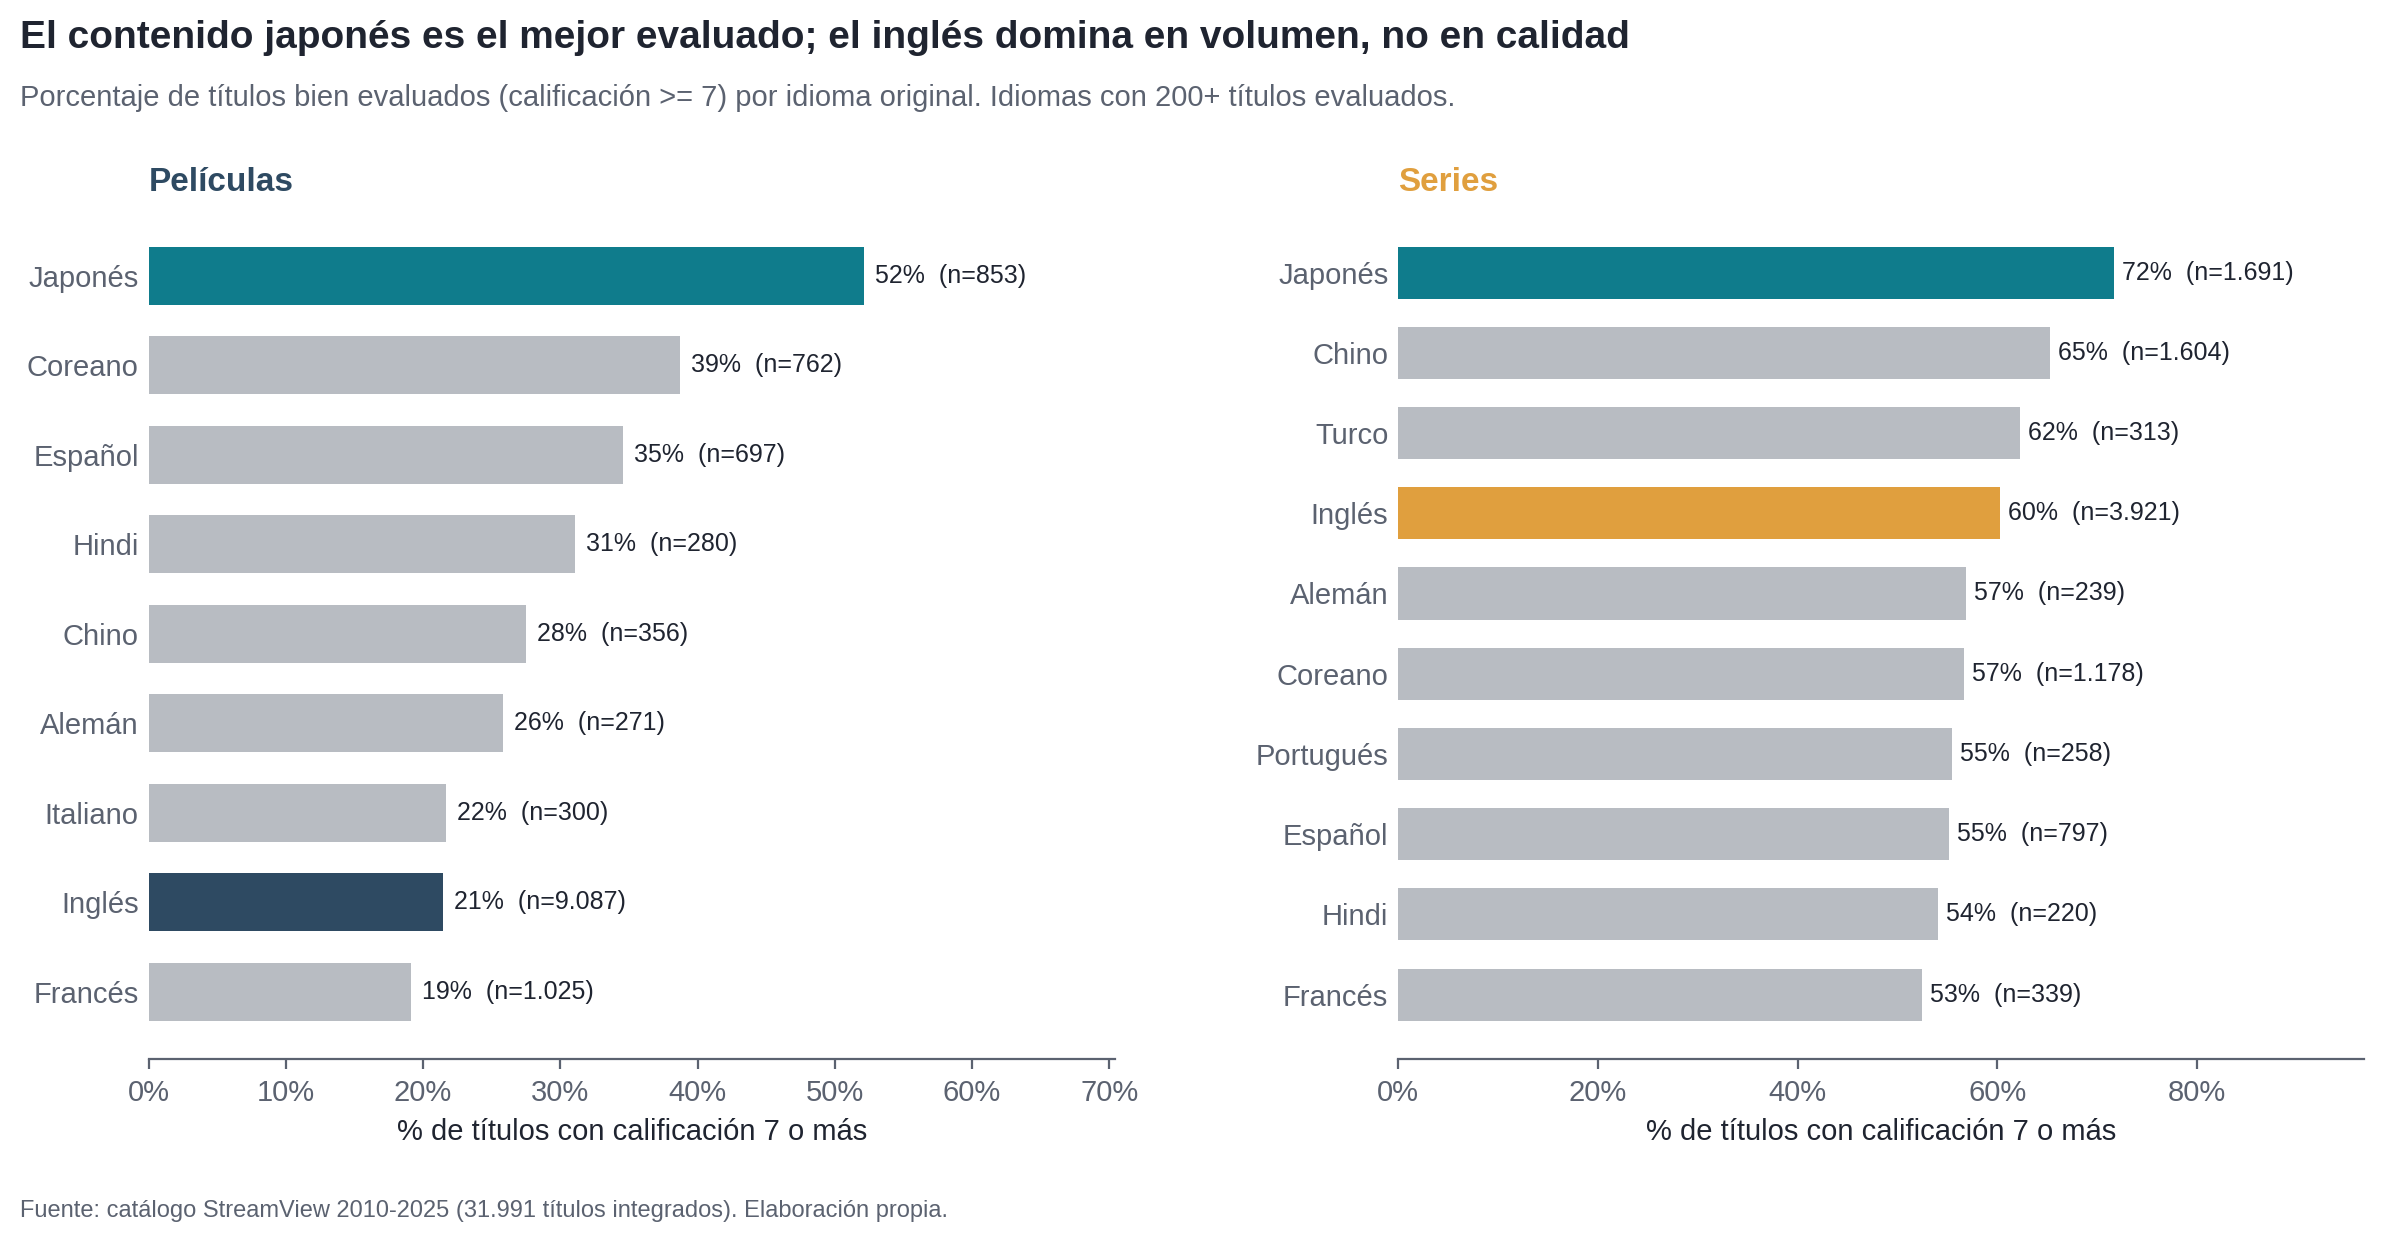

,tipo,idioma,titulos,votos,calif_ponderada,pct_calif_alta
8,Película,Japonés,853,179418,6.59,52.17
2,Película,Coreano,762,121818,6.49,38.71
3,Película,Español,697,180618,6.49,34.58
5,Película,Hindi,280,37049,6.42,31.07
1,Película,Chino,356,44408,6.44,27.53
0,Película,Alemán,271,57798,6.43,25.83
7,Película,Italiano,300,120469,6.31,21.67
6,Película,Inglés,9087,10130522,6.33,21.48
4,Película,Francés,1025,373001,6.33,19.12
16,Serie,Japonés,1691,212542,7.31,71.67


In [6]:
display(Image(gr.fig_idiomas(cat)))
met.tabla_idiomas(cat).sort_values(["tipo","pct_calif_alta"], ascending=[True, False]).round(2)

## P5. ¿Cómo evoluciona la calidad del catálogo en el tiempo?

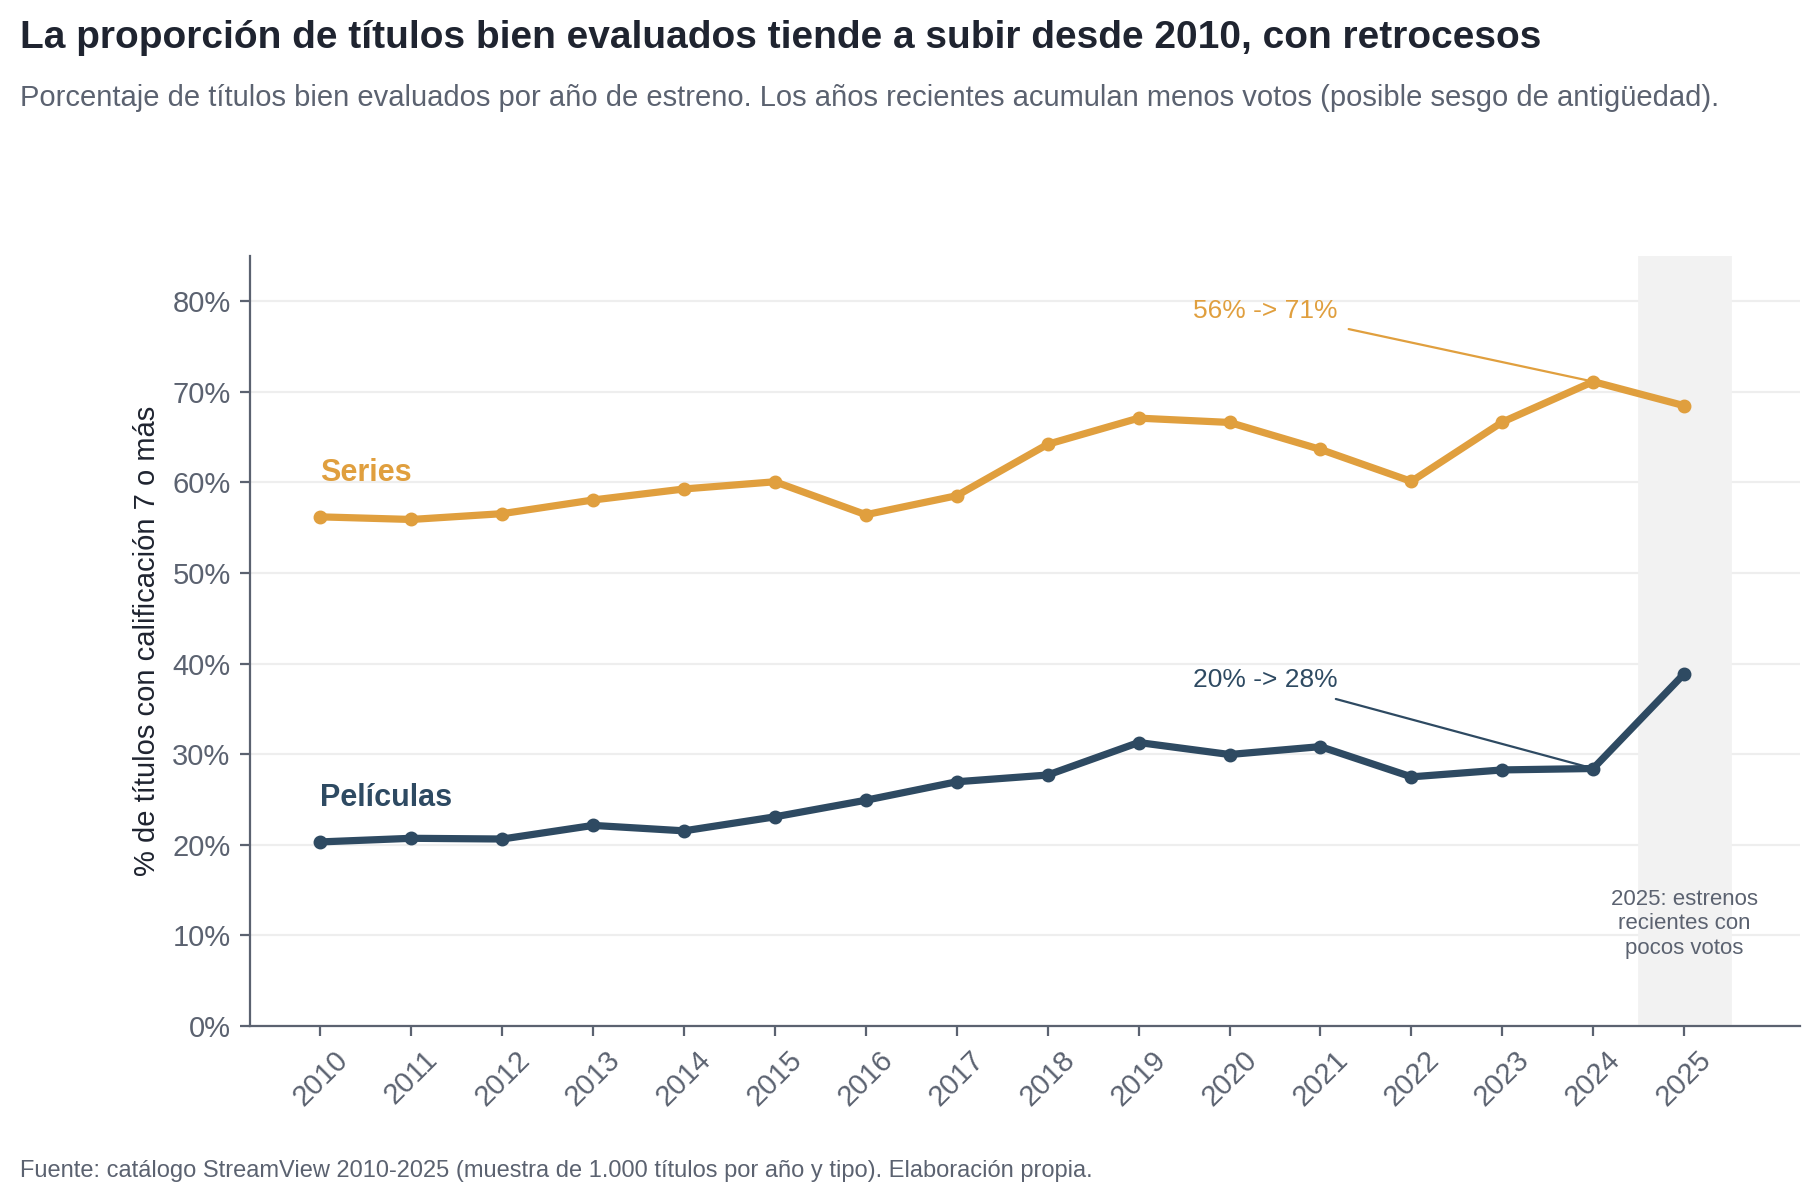

In [7]:
display(Image(gr.fig_tendencia(cat)))

## P6. ¿La popularidad refleja satisfacción?

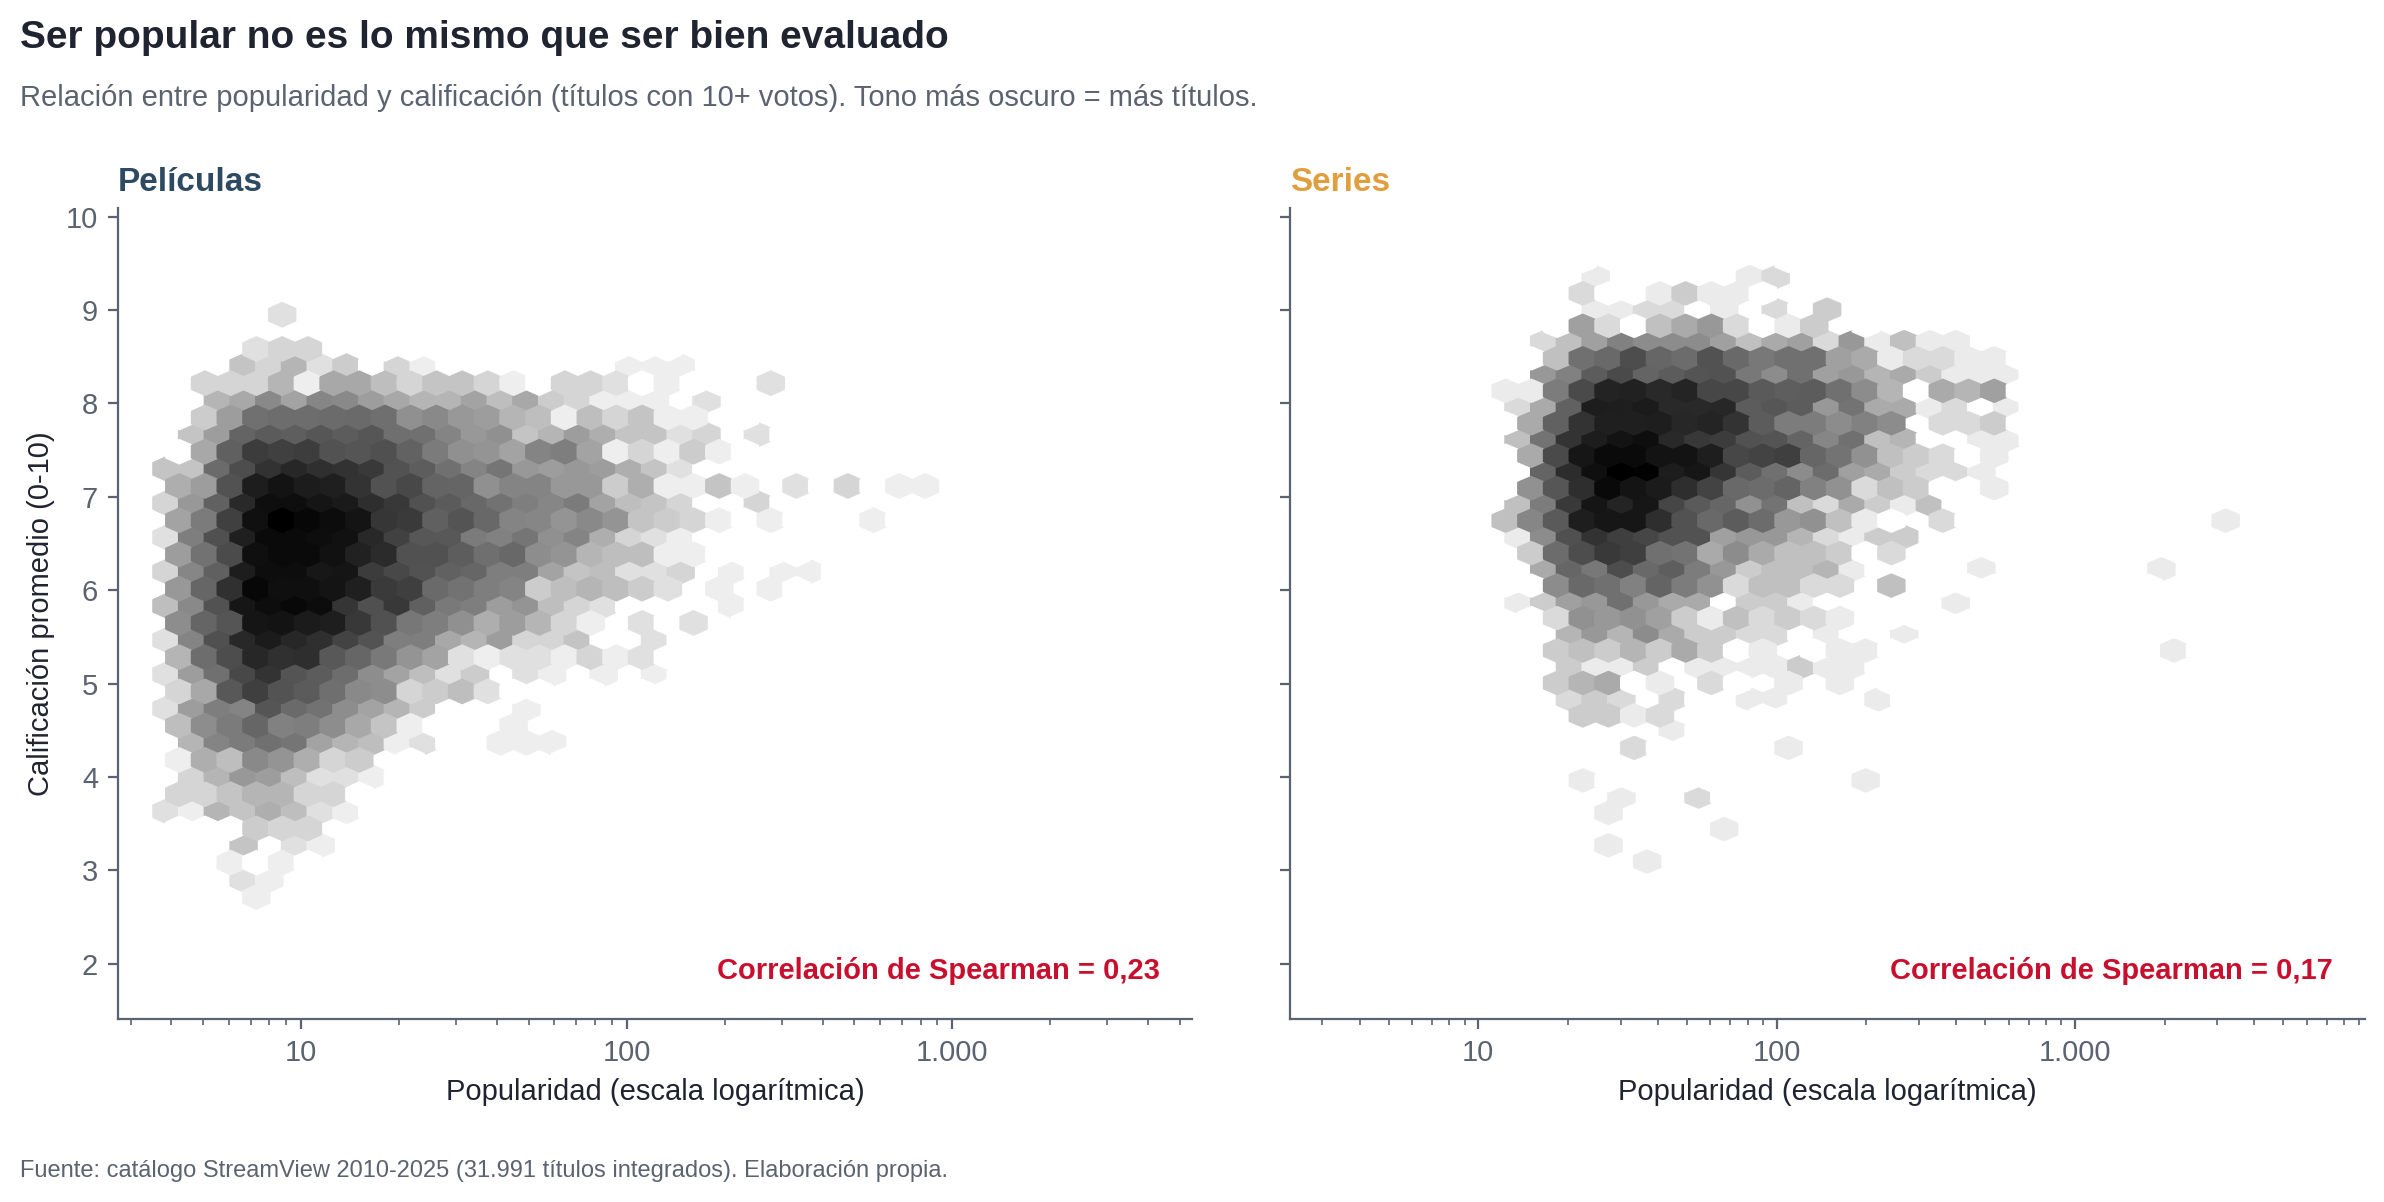

{'Película':                  popularidad  votos  calificacion  calif_ponderada
 popularidad             1.00   0.52          0.23             0.26
 votos                   0.52   1.00          0.22             0.25
 calificacion            0.23   0.22          1.00             0.95
 calif_ponderada         0.26   0.25          0.95             1.00,
 'Serie':                  popularidad  votos  calificacion  calif_ponderada
 popularidad             1.00   0.26          0.17             0.19
 votos                   0.26   1.00          0.32             0.41
 calificacion            0.17   0.32          1.00             0.99
 calif_ponderada         0.19   0.41          0.99             1.00}

In [8]:
display(Image(gr.fig_popularidad_calidad(cat)))
{t: m.round(2) for t, m in met.correlaciones(cat).items()}

## P7. ¿Qué géneros de películas son más rentables y cómo afectó la pandemia?

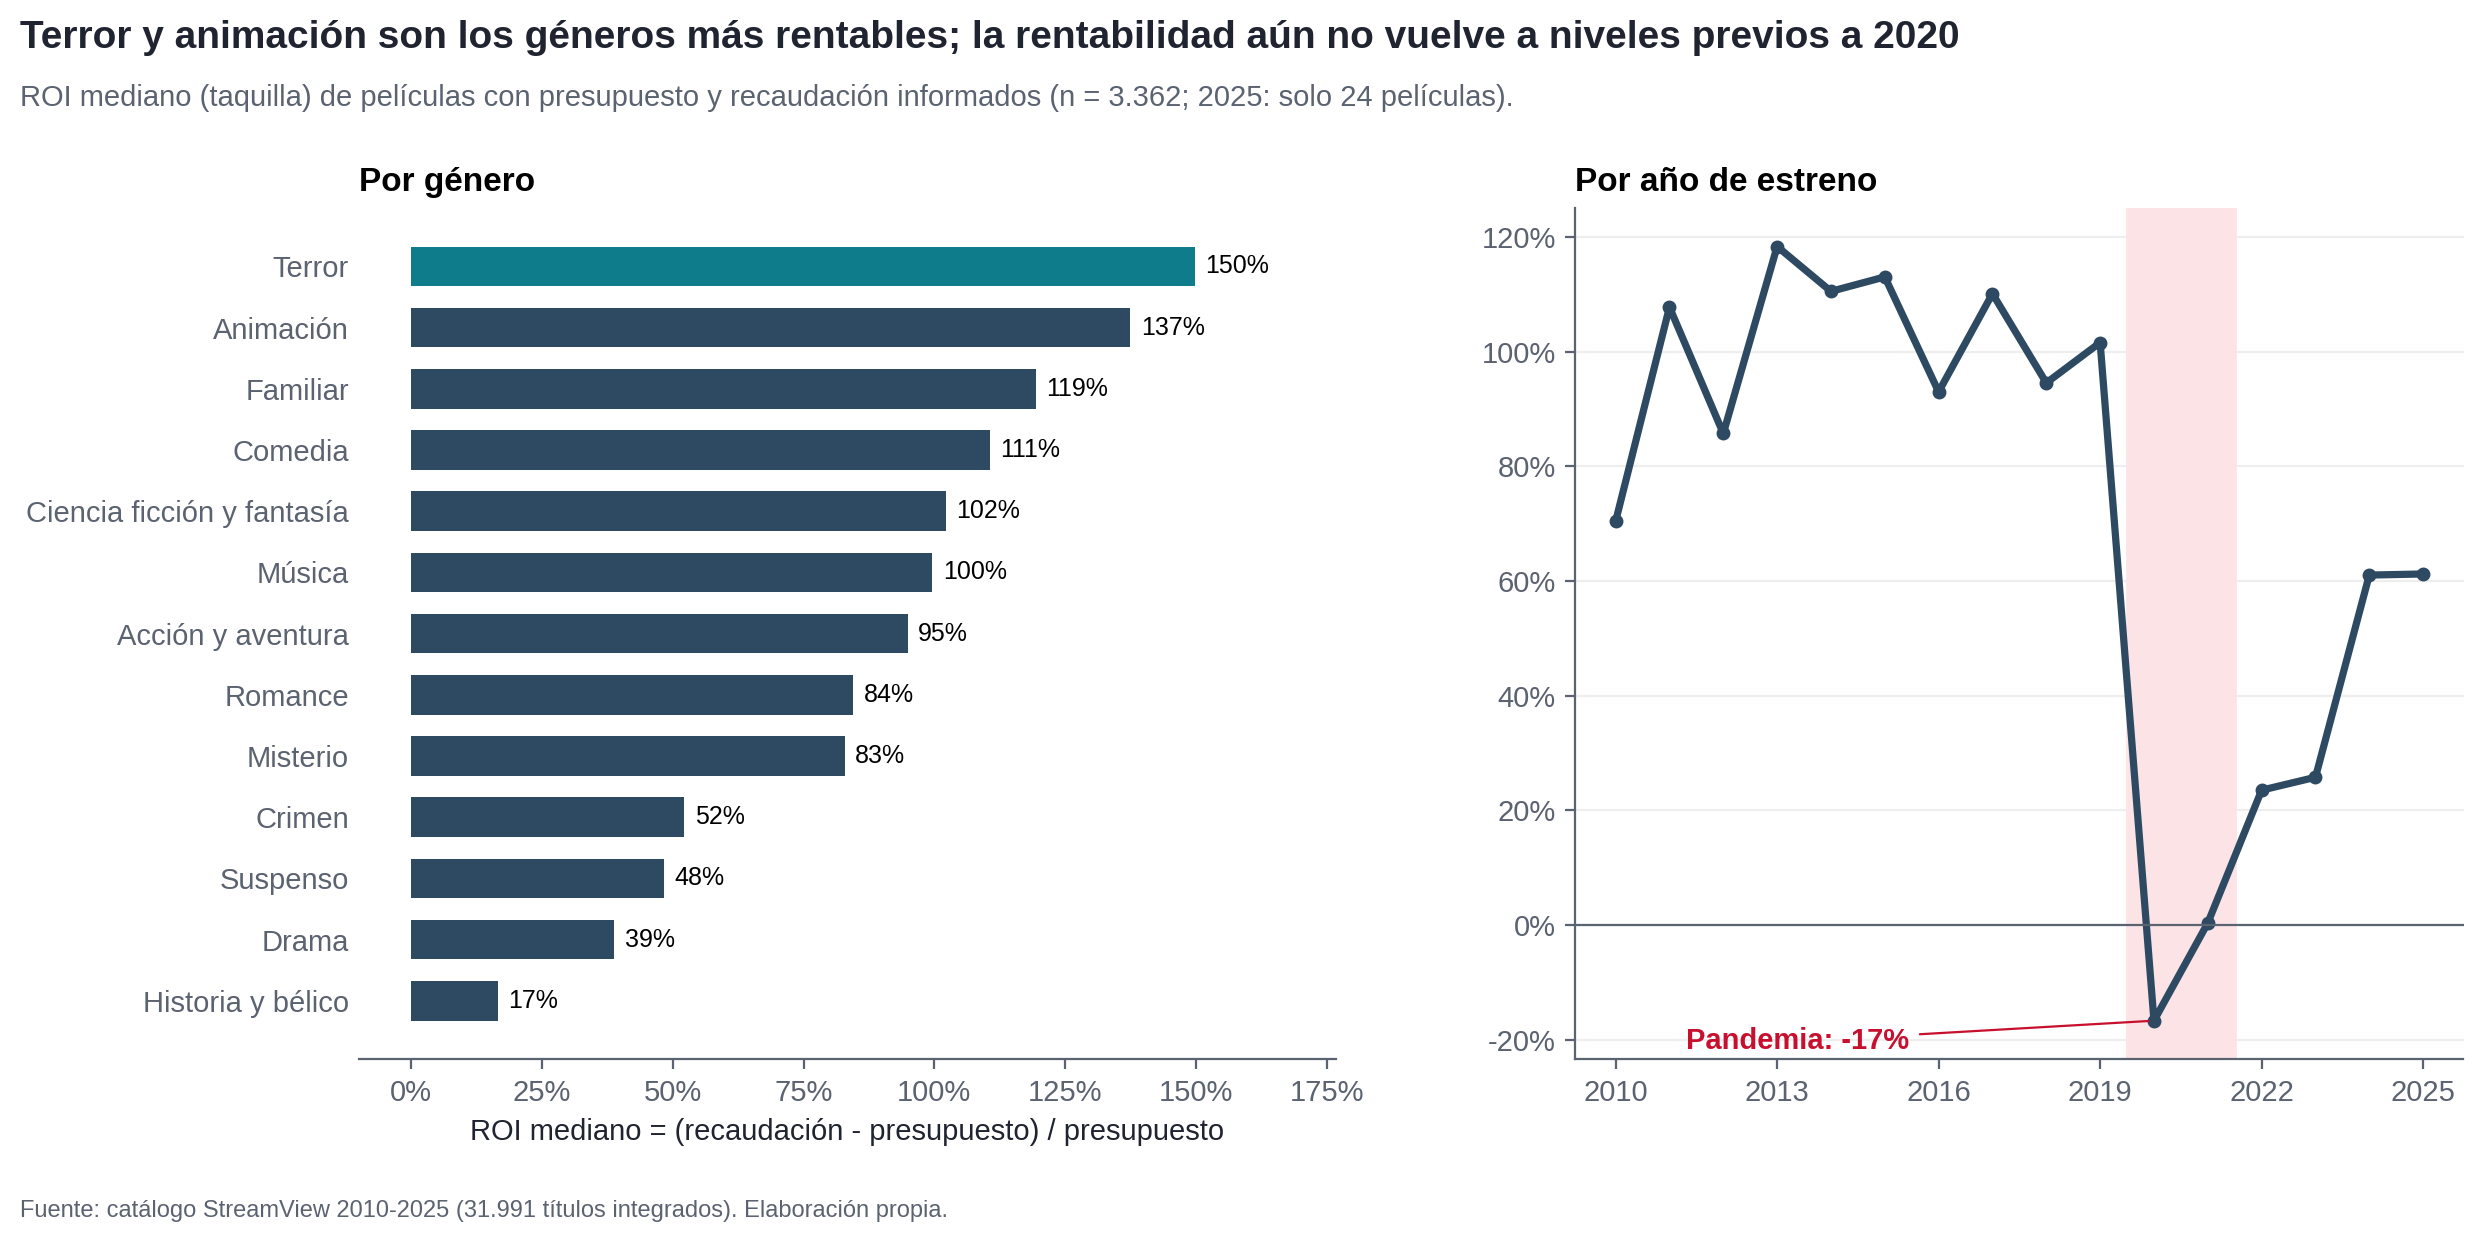

,anio,roi_mediano
0,2010,70.4
1,2011,107.8
2,2012,85.7
3,2013,118.4
4,2014,110.5
5,2015,113.1
6,2016,93.0
7,2017,110.1
8,2018,94.6
9,2019,101.6


In [9]:
display(Image(gr.fig_roi(cat, tg)))
met.tabla_anual(cat).query("tipo == 'Película'")[["anio","roi_mediano"]].round(1)

## P8. ¿De dónde proviene el contenido?

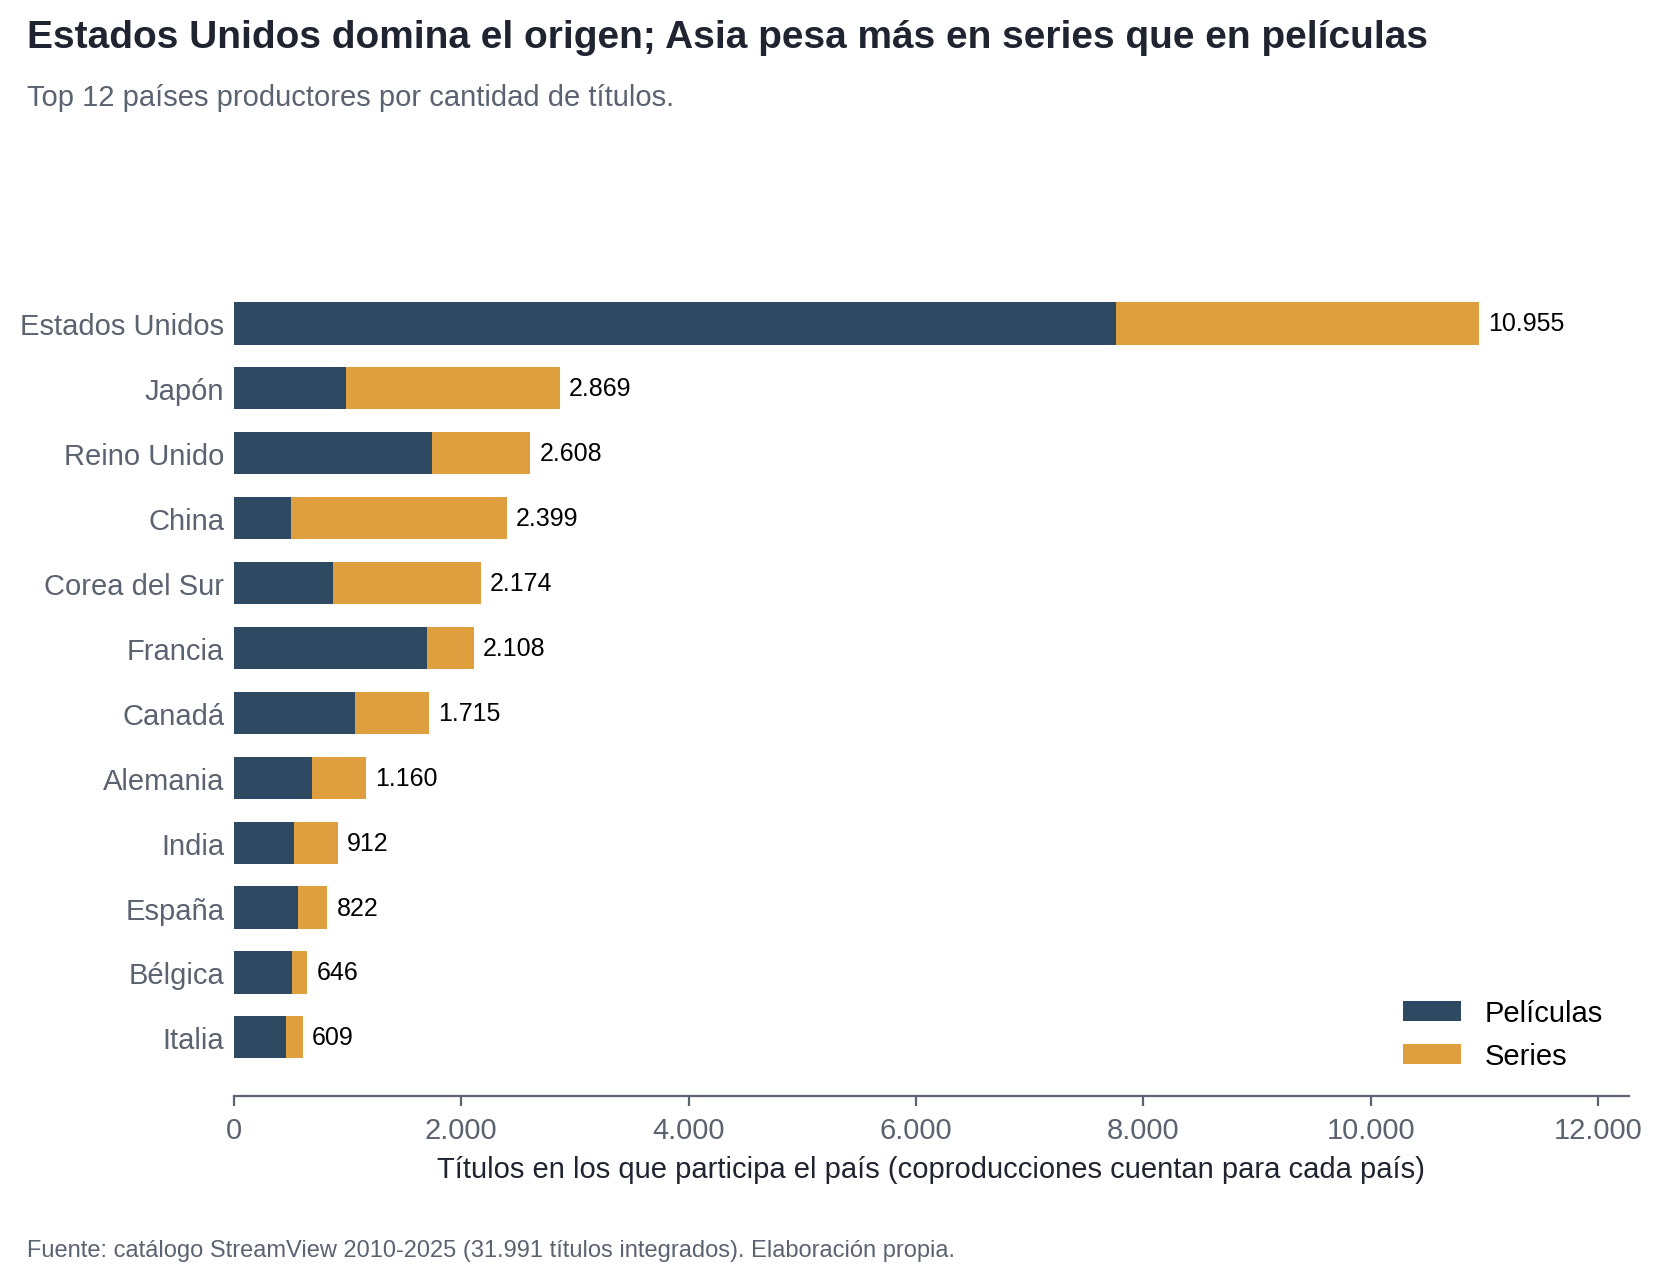

In [10]:
display(Image(gr.fig_paises(pai)))

## Síntesis de hallazgos (verificados)
1. La interacción está muy concentrada: el 10% de los títulos reúne el 71% (películas) y 86% (series) de los votos; 62% de las series tiene menos de 10 votos.
2. Ciencia ficción y fantasía, acción y aventura, misterio y crimen rinden hasta 2,5 veces su peso en las asignaciones de género (series); reality, talk show y documental menos de 0,25 veces.
3. Documental, música e historia están bien evaluados pero poco descubiertos (joyas ocultas); en películas, drama y romance también caen en ese cuadrante, cerca del umbral de calidad. Terror tiene baja calidad y baja tracción (x0,74).
4. Entre idiomas con 200+ títulos evaluados, el japonés es el mejor evaluado (52% de películas y 72% de series con nota 7+). En películas el resultado es robusto al mínimo de votos; en series no (ver tabla de robustez abajo).
5. Popularidad y calificación se relacionan débilmente (Spearman 0,23 películas y 0,17 series).
6. La proporción de títulos bien evaluados tiende a subir entre 2010 y 2024, con retrocesos (películas: máximo en 2019); parte del alza puede ser sesgo de antigüedad.
7. El ROI mediano de películas cayó a -17% en 2020 y en 2024 ronda 61% (2025 solo tiene 24 películas con datos), bajo el ~100% previo a la pandemia; terror y animación son los más rentables.

## Robustez: % de títulos con nota 7+ por idioma según votos mínimos
Idiomas con 100+ títulos en cada umbral. Top 5 por tipo.

In [11]:
filas = []
for mv in [1, 10, 50]:
    e = cat[cat.votos >= mv]
    t = e.groupby(["tipo", "idioma"]).agg(titulos=("id", "size"), pct_7=("calificacion", lambda s: (s >= 7).mean() * 100))
    t = t[t.titulos >= 100].reset_index()
    t["votos_min"] = mv
    filas.append(t.sort_values("pct_7", ascending=False).groupby("tipo").head(5))
pd.concat(filas).round(1)

,tipo,idioma,titulos,pct_7,votos_min
13,Serie,Cantonés,113,82.3,1
26,Serie,Tailandés,143,78.3,1
24,Serie,Ruso,184,73.4,1
21,Serie,Japonés,1691,71.7,1
22,Serie,Neerlandés,145,66.2,1
8,Película,Japonés,853,52.2,1
9,Película,Portugués,123,40.7,1
2,Película,Coreano,762,38.7,1
3,Película,Español,697,34.6,1
5,Película,Hindi,280,31.1,1
